# 03 - Train FlexScaleSR

**Running this notebook top to bottom does NOT start long training.**
It goes as far as a smoke test and a short 8-epoch trial run on 8 images,
then stops. Full training lives in the last section behind a flag you have to
set yourself.

Trial checkpoints are written to `experiments/trial_run/`, never to
`checkpoints/`, so a throwaway run can never be mistaken for the final model.

## The pipeline

```
LR tif
  |
  v  SatelliteSRDataset      band reorder [2,1,0,3], HR / 10000
  v  paired augmentation     same flip / rotation applied to LR and HR
  v  SameSizeBatchSampler    only batch tiles that share an HR size
  v  DataLoader
  |
  v  FlexScaleSR(lr, target_hw)
  |
  v  Charbonnier + 0.1 * SAM + 0.05 * Gradient
  v  backpropagation -> Adam -> cosine LR schedule
  |
  v  validation: loss, PSNR, SSIM
  v  checkpoint: best.pt (by val PSNR) and last.pt (every epoch)
```

## A. Configuration

In [1]:
import sys, os, json, time

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.data import SatelliteSRDataset, make_loader
from src.model import build_model, count_parameters
from src.losses import build_loss
from src.metrics import compute_all
from src.train_utils import (load_config, set_seed, get_device, fit,
                             train_one_epoch, validate, save_checkpoint,
                             load_checkpoint, describe_checkpoint)
from src.inference import bicubic_upsample, predict, save_prediction
from src.visualize import plot_history, comparison_panel

CONFIG_PATH = "configs/baseline.yaml"
cfg = load_config(CONFIG_PATH)

set_seed(cfg["training"]["seed"])
device = get_device(cfg["training"]["device"])

print(json.dumps(cfg, indent=2))
print()
print("device:", device)
if device.type == "cuda":
    print("gpu   :", torch.cuda.get_device_name(0),
          "({:.1f} GB)".format(torch.cuda.get_device_properties(0).total_memory / 1e9))

{
  "data": {
    "root": "E:/Hackathon",
    "hr_scale": 10000.0,
    "lr_band_order": [
      "B",
      "G",
      "R",
      "NIR"
    ],
    "hr_band_order": [
      "R",
      "G",
      "B",
      "NIR"
    ],
    "canonical_band_order": [
      "R",
      "G",
      "B",
      "NIR"
    ]
  },
  "model": {
    "in_channels": 4,
    "out_channels": 4,
    "features": 64,
    "num_res_blocks": 12,
    "upsample_factor": 8,
    "max_reflectance": 1.5
  },
  "metrics": {
    "sam_min_norm": 0.001,
    "ergas_dark_band_threshold": 0.02
  },
  "training": {
    "device": "auto",
    "seed": 42,
    "batch_size": 4,
    "epochs": 100,
    "learning_rate": 0.0002,
    "weight_decay": 1e-05,
    "mixed_precision": true,
    "early_stopping_patience": 20,
    "num_workers": 0,
    "augment": true
  },
  "loss": {
    "charbonnier_weight": 1.0,
    "sam_weight": 0.1,
    "gradient_weight": 0.05
  },
  "smoke_test": {
    "max_train_samples": 8,
    "max_val_samples": 4,
    "epochs": 2,
 

### Why these config values

| setting | value | reason |
|---|---|---|
| `features` / `num_res_blocks` | 64 / 12 | about 1.39 M parameters. Only 100 training images, so a bigger model would memorise them. |
| `upsample_factor` | 8 | The real scale factor is 6.4x to 7.0x. Upsampling by 8 and then shrinking is safer than upsampling by 4 and stretching. |
| `batch_size` | 4 | Fits in 6 GB with a 384x384x64 intermediate feature map. |
| `learning_rate` | 2e-4 | Standard for Adam on SR networks. |
| `mixed_precision` | true | Roughly halves memory use on an NVIDIA GPU; ignored on CPU. |
| `epochs` | 100 | With early stopping after 20 epochs without improvement. |

## B. Dataset loading

In [2]:
HR_SCALE = cfg["data"]["hr_scale"]

train_ds = SatelliteSRDataset(".", "train", HR_SCALE,
                              augment=cfg["training"]["augment"],
                              seed=cfg["training"]["seed"])
val_ds = SatelliteSRDataset(".", "val", HR_SCALE, augment=False)

print("train pairs:", len(train_ds))
print("val pairs  :", len(val_ds))

s = train_ds[0]
print()
print("one sample:")
print("  name:", s["name"])
print("  lr  :", tuple(s["lr"].shape), s["lr"].dtype,
      "range %.4f..%.4f" % (s["lr"].min(), s["lr"].max()))
print("  hr  :", tuple(s["hr"].shape), s["hr"].dtype,
      "range %.4f..%.4f" % (s["hr"].min(), s["hr"].max()))
print()
print("Both are reflectance and both are in canonical [R, G, B, NIR] order.")

train pairs: 100
val pairs  : 20

one sample:
  name: 1.tif
  lr  : (4, 48, 48) torch.float32 range 0.0101..0.3694
  hr  : (4, 318, 322) torch.float32 range 0.0007..0.4701

Both are reflectance and both are in canonical [R, G, B, NIR] order.


### Augmentation check

The same geometric transform must hit LR and HR. If they drifted apart the model
would be trained on mismatched pairs and would learn nothing useful.

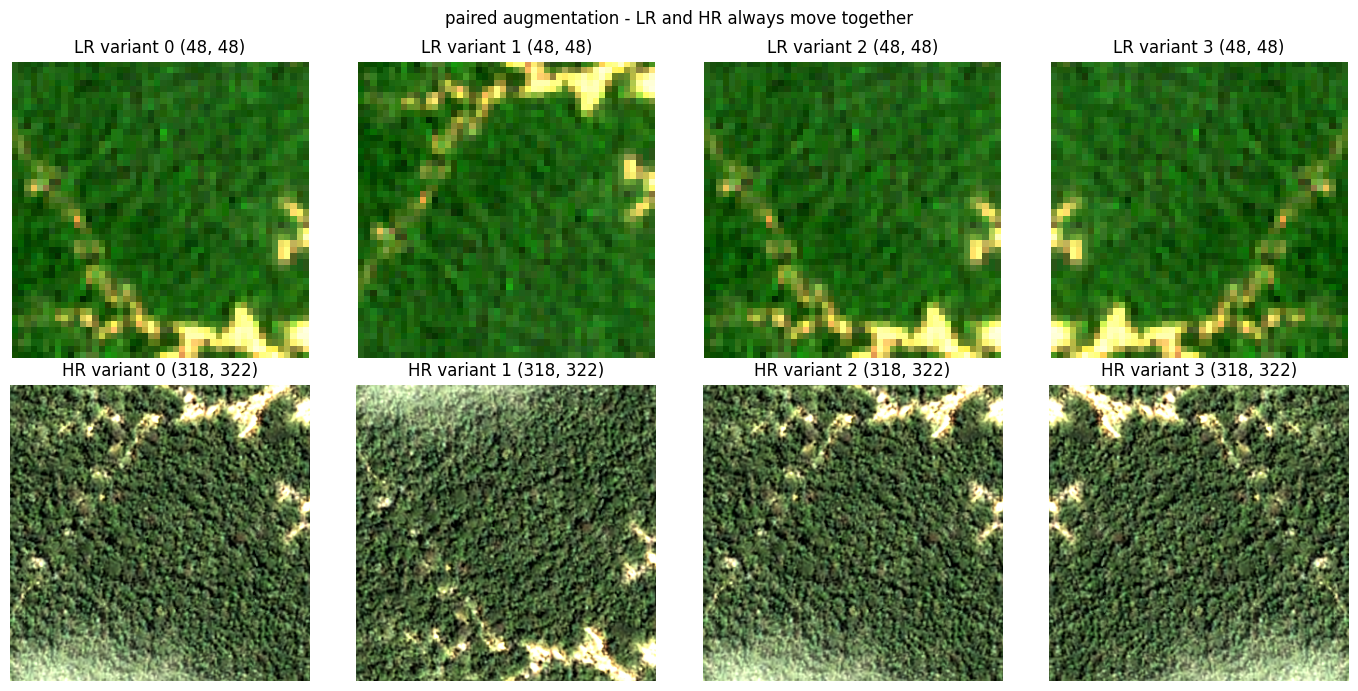

In [3]:
from src.data import paired_augment

lr0 = train_ds[0]["lr"].numpy().transpose(1, 2, 0)
hr0 = train_ds[0]["hr"].numpy().transpose(1, 2, 0)
rng = np.random.default_rng(3)

fig, ax = plt.subplots(2, 4, figsize=(14, 7))
from src.visualize import to_rgb
for k in range(4):
    a, b = paired_augment(lr0.copy(), hr0.copy(), rng)
    ax[0, k].imshow(to_rgb(a)); ax[0, k].set_title("LR variant %d %s" % (k, a.shape[:2]))
    ax[1, k].imshow(to_rgb(b)); ax[1, k].set_title("HR variant %d %s" % (k, b.shape[:2]))
    ax[0, k].axis("off"); ax[1, k].axis("off")
fig.suptitle("paired augmentation - LR and HR always move together")
plt.tight_layout(); plt.show()

## C. DataLoader

HR tiles have 22 different sizes in the training split, so they cannot all be
stacked into one tensor. `SameSizeBatchSampler` groups tiles by HR size and only
batches within a group. The ground truth is never resized.

In [4]:
train_loader = make_loader(train_ds, cfg["training"]["batch_size"], shuffle=True,
                           seed=cfg["training"]["seed"],
                           num_workers=cfg["training"]["num_workers"])
val_loader = make_loader(val_ds, cfg["training"]["batch_size"], shuffle=False,
                         num_workers=cfg["training"]["num_workers"])

print("train batches per epoch:", len(train_loader))
print("val batches per epoch  :", len(val_loader))
print()
for i, b in enumerate(train_loader):
    print("  batch %d: lr %s  hr %s  files %s" %
          (i, tuple(b["lr"].shape), tuple(b["hr"].shape), b["name"]))
    if i == 4:
        break

train batches per epoch: 37
val batches per epoch  : 11

  batch 0: lr (4, 4, 48, 48)  hr (4, 4, 318, 321)  files ['81.tif', '69.tif', '77.tif', '30.tif']
  batch 1: lr (4, 4, 48, 48)  hr (4, 4, 318, 322)  files ['23.tif', '1.tif', '78.tif', '17.tif']
  batch 2: lr (1, 4, 48, 48)  hr (1, 4, 310, 329)  files ['84.tif']
  batch 3: lr (2, 4, 48, 48)  hr (2, 4, 314, 326)  files ['34.tif', '47.tif']
  batch 4: lr (1, 4, 48, 48)  hr (1, 4, 321, 318)  files ['82.tif']


## D. Model creation

In [5]:
model = build_model(cfg).to(device)
n_params = count_parameters(model)
print(model)
print()
print("trainable parameters: {:,}  ({:.2f} M)".format(n_params, n_params / 1e6))

FlexScaleSR(
  (head): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
    )
    (3): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=Tr

### The flexible output size, demonstrated

One model, three different requested sizes, three exact matches. Nothing in the
network is tied to 320x320.

In [6]:
x = torch.randn(1, 4, 48, 48, device=device)
with torch.no_grad():
    for hw in [(307, 336), (321, 321), (336, 307)]:
        y = model(x, hw)
        print("target {} -> output {}  match: {}".format(
            hw, tuple(y.shape[-2:]), tuple(y.shape[-2:]) == hw))

target (307, 336) -> output (307, 336)  match: True
target (321, 321) -> output (321, 321)  match: True
target (336, 307) -> output (336, 307)  match: True


## E. Loss creation

`Charbonnier + 0.1 * SAM + 0.05 * Gradient`

- **Charbonnier** gets the pixel values right, robustly.
- **SAM** gets the colour and the spectrum right, which protects NIR.
- **Gradient** keeps the edges from going blurry.

In [7]:
loss_fn = build_loss(cfg)
print("weights: charbonnier %.2f | sam %.2f | gradient %.2f" %
      (loss_fn.w_char, loss_fn.w_sam, loss_fn.w_grad))

b = next(iter(train_loader))
lr_b, hr_b = b["lr"].to(device), b["hr"].to(device)
with torch.no_grad():
    pred_b = model(lr_b, (hr_b.shape[-2], hr_b.shape[-1]))
    total, parts = loss_fn(pred_b, hr_b)
print()
print("untrained model on one batch:")
print("  total       %.5f" % total.item())
for k, v in parts.items():
    print("  %-11s %.5f" % (k, v))

weights: charbonnier 1.00 | sam 0.10 | gradient 0.05



untrained model on one batch:
  total       0.04471
  charbonnier 0.02463
  sam         0.19507
  gradient    0.01130


## F. Smoke test

Fifteen checks on a tiny subset. This is the cell to run whenever anything
changes: it exercises the entire pipeline in a few seconds, so a broken step is
found immediately instead of thirty minutes into a training run.

In [8]:
st = cfg["smoke_test"]
set_seed(cfg["training"]["seed"])

sm_train = SatelliteSRDataset(".", "train", HR_SCALE, augment=True,
                              max_samples=st["max_train_samples"], seed=0)
sm_val = SatelliteSRDataset(".", "val", HR_SCALE, augment=False,
                            max_samples=st["max_val_samples"])
sm_train_loader = make_loader(sm_train, st["batch_size"], shuffle=True)
sm_val_loader = make_loader(sm_val, st["batch_size"], shuffle=False)

passed = []
def check(n, label, ok, extra=""):
    passed.append(bool(ok))
    print("  [%2d] %s  %-34s %s" % (n, "PASS" if ok else "FAIL", label, extra))

t0 = time.time()
sm_model = build_model(cfg).to(device)
sm_loss = build_loss(cfg)
sm_opt = torch.optim.Adam(sm_model.parameters(), lr=cfg["training"]["learning_rate"])

# 1-3 loading, band order, scaling
from src.data import load_pair, read_tif, reorder_lr_bands
lr_np, hr_np = load_pair("train/LR/1.tif", "train/HR/1.tif", HR_SCALE)
check(1, "TIFF loading", lr_np.shape == (48, 48, 4) and hr_np.shape[2] == 4,
      "lr %s hr %s" % (lr_np.shape, hr_np.shape))
raw = read_tif("train/LR/1.tif")
check(2, "band reorder, NIR preserved",
      np.array_equal(reorder_lr_bands(raw)[..., 0], raw[..., 2]) and
      np.array_equal(reorder_lr_bands(raw)[..., 3], raw[..., 3]))
check(3, "reflectance conversion", 0 < hr_np.mean() < 1.5,
      "lr %.4f hr %.4f" % (lr_np.mean(), hr_np.mean()))

# 4 dataloader
bb = next(iter(sm_train_loader))
check(4, "DataLoader", bb["lr"].shape[1] == 4 and bb["hr"].shape[1] == 4,
      "lr %s hr %s" % (tuple(bb["lr"].shape), tuple(bb["hr"].shape)))

# 5-6 model + forward
check(5, "model creation", count_parameters(sm_model) > 0,
      "{:,} params".format(count_parameters(sm_model)))
lr_t, hr_t = bb["lr"].to(device), bb["hr"].to(device)
out = sm_model(lr_t, (hr_t.shape[-2], hr_t.shape[-1]))
check(6, "forward, exact output size", out.shape == hr_t.shape, str(tuple(out.shape)))

# 7-9 loss, backward, optimizer
l, pr = sm_loss(out, hr_t)
check(7, "loss computation", torch.isfinite(l), "%.5f" % l.item())
l.backward()
gsum = sum(float(p.grad.abs().sum()) for p in sm_model.parameters() if p.grad is not None)
check(8, "backward pass", gsum > 0, "total |grad| %.2f" % gsum)
w_before = sm_model.head.weight.detach().clone()
sm_opt.step(); sm_opt.zero_grad(set_to_none=True)
check(9, "optimizer step", not torch.equal(w_before, sm_model.head.weight))

# 10-11 validation + checkpoint save
vl, vp, vs = validate(sm_model, sm_val_loader, sm_loss, device)
check(10, "validation", np.isfinite(vp), "loss %.4f PSNR %.2f SSIM %.3f" % (vl, vp, vs))
TRIAL_DIR = "experiments/trial_run"     # never the real checkpoints folder
os.makedirs(TRIAL_DIR, exist_ok=True)
save_checkpoint(os.path.join(TRIAL_DIR, "_smoke.pt"), sm_model, sm_opt, None, 0,
                {"val_psnr": vp}, cfg, {"run_type": "smoke"})
check(11, "checkpoint save", os.path.exists(os.path.join(TRIAL_DIR, "_smoke.pt")))

# 12 checkpoint load
reloaded = build_model(cfg).to(device)
ck = load_checkpoint(os.path.join(TRIAL_DIR, "_smoke.pt"), reloaded, device=device)
same = all(torch.equal(a, b_) for a, b_ in
           zip(sm_model.state_dict().values(), reloaded.state_dict().values()))
check(12, "checkpoint load", same, "epoch %s" % ck["epoch"])

# 13-14 inference + output save
pred_np = predict(reloaded, lr_np, hr_np.shape[:2], device)
check(13, "inference", pred_np.shape == hr_np.shape, str(pred_np.shape))
save_prediction("outputs/predictions/_smoke.tif", pred_np, reference_tif="train/HR/1.tif")
import tifffile
back = tifffile.imread("outputs/predictions/_smoke.tif")
check(14, "GeoTIFF write and read back",
      back.shape == pred_np.shape and back.dtype == np.float32,
      "%s %s" % (back.shape, back.dtype))

# 15 metrics
mm = compute_all(pred_np, hr_np, lr_shape=(48, 48))
check(15, "metrics", all(np.isfinite(v) for v in mm.values()),
      "PSNR %.2f SSIM %.3f SAM %.2f" % (mm["psnr"], mm["ssim"], mm["sam"]))

os.remove(os.path.join(TRIAL_DIR, "_smoke.pt"))
os.remove("outputs/predictions/_smoke.tif")
print()
print("SMOKE TEST: %d/%d passed in %.1fs" % (sum(passed), len(passed), time.time() - t0))
assert all(passed), "smoke test failed - fix before training"


  [ 1] PASS  TIFF loading                       lr (48, 48, 4) hr (318, 322, 4)
  [ 2] PASS  band reorder, NIR preserved        
  [ 3] PASS  reflectance conversion             lr 0.0910 hr 0.0585
  [ 4] PASS  DataLoader                         lr (1, 4, 48, 48) hr (1, 4, 317, 325)
  [ 5] PASS  model creation                     1,388,324 params
  [ 6] PASS  forward, exact output size         (1, 4, 317, 325)
  [ 7] PASS  loss computation                   0.05125


  [ 8] PASS  backward pass                      total |grad| 22.01
  [ 9] PASS  optimizer step                     


  [10] PASS  validation                         loss 0.0630 PSNR 23.92 SSIM 0.710
  [11] PASS  checkpoint save                    
  [12] PASS  checkpoint load                    epoch 0
  [13] PASS  inference                          (318, 322, 4)


  [14] PASS  GeoTIFF write and read back        (318, 322, 4) float32
  [15] PASS  metrics                            PSNR 25.46 SSIM 0.597 SAM 10.29

SMOKE TEST: 15/15 passed in 2.7s


## G. Tiny training run

Eight epochs on 8 training images. The goal is **not** a good model. The goal is
to confirm that the loss falls smoothly and that checkpoints appear, which means
the plumbing is correct. Output goes to `experiments/trial_run/`.

In [9]:
set_seed(cfg["training"]["seed"])
tiny_model = build_model(cfg).to(device)
tiny_hist = fit(tiny_model, sm_train_loader, sm_val_loader, loss_fn, cfg, device,
                epochs=8, ckpt_dir=TRIAL_DIR, verbose=True, run_type="trial")

print()
print("train loss went from %.5f to %.5f" %
      (tiny_hist["train_loss"][0], tiny_hist["train_loss"][-1]))
print("loss decreased:", tiny_hist["train_loss"][-1] < tiny_hist["train_loss"][0])
print("trial checkpoints:", sorted(f for f in os.listdir(TRIAL_DIR) if f.endswith(".pt")))
print("real checkpoints/ folder:",
      sorted(f for f in os.listdir("checkpoints")) if os.path.isdir("checkpoints") else "empty")
print()
print("Trial checkpoints are written to", TRIAL_DIR, "on purpose, so they can")
print("never be mistaken for the final model in checkpoints/.")

epoch   1/8  train 0.05991  val 0.05778  PSNR  24.42  SSIM 0.7247  (0.8s)
          new best (PSNR 24.42) -> best.pt


epoch   2/8  train 0.05430  val 0.05850  PSNR  24.25  SSIM 0.7147  (0.6s)


epoch   3/8  train 0.05138  val 0.05886  PSNR  24.39  SSIM 0.7115  (0.6s)


epoch   4/8  train 0.05069  val 0.05850  PSNR  24.40  SSIM 0.7125  (0.7s)


epoch   5/8  train 0.04984  val 0.05853  PSNR  24.57  SSIM 0.7095  (0.5s)
          new best (PSNR 24.57) -> best.pt


epoch   6/8  train 0.04906  val 0.05843  PSNR  24.60  SSIM 0.7088  (0.6s)
          new best (PSNR 24.60) -> best.pt


epoch   7/8  train 0.04840  val 0.05847  PSNR  24.71  SSIM 0.7072  (0.6s)
          new best (PSNR 24.71) -> best.pt


epoch   8/8  train 0.04787  val 0.05848  PSNR  24.73  SSIM 0.7069  (0.6s)
          new best (PSNR 24.73) -> best.pt

train loss went from 0.05991 to 0.04787
loss decreased: True
trial checkpoints: ['best.pt', 'last.pt']
real checkpoints/ folder: []

Trial checkpoints are written to experiments/trial_run on purpose, so they can
never be mistaken for the final model in checkpoints/.


### Is the tiny run numerically stable?

Before trusting a long run, check the short one for the classic warning signs:
a loss that goes to NaN, a loss that jumps around instead of falling, or a
validation score that collapses.

train loss : [0.05991, 0.0543, 0.05138, 0.05069, 0.04984, 0.04906, 0.0484, 0.04787]
val   loss : [0.05778, 0.0585, 0.05886, 0.0585, 0.05853, 0.05843, 0.05847, 0.05848]
val   PSNR : [24.417, 24.252, 24.386, 24.403, 24.566, 24.595, 24.71, 24.734]

all values finite            : True
train loss decreased         : True
strictly monotone decrease   : True
largest single-epoch swing   : 9.4%  (over ~50% would mean trouble)


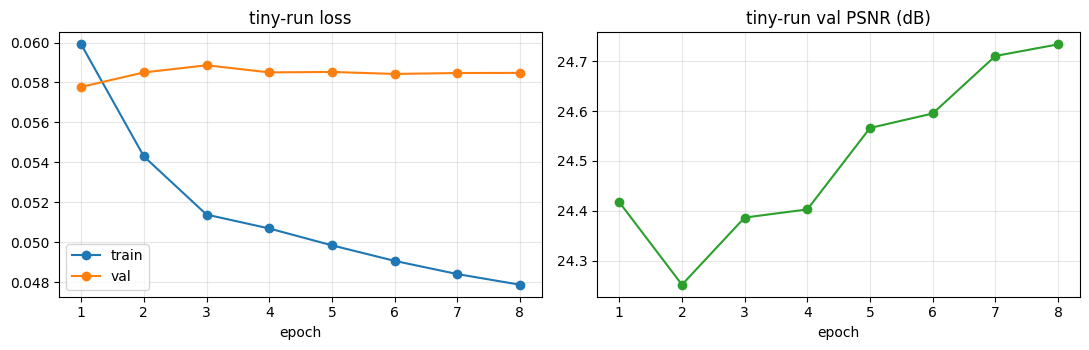

In [10]:
tr_l = np.array(tiny_hist["train_loss"])
va_l = np.array(tiny_hist["val_loss"])
swing = 100 * (np.abs(np.diff(tr_l)) / np.maximum(np.abs(tr_l[:-1]), 1e-12)).max()

print("train loss :", np.round(tr_l, 5).tolist())
print("val   loss :", np.round(va_l, 5).tolist())
print("val   PSNR :", np.round(tiny_hist["val_psnr"], 3).tolist())
print()
print("all values finite            :", bool(np.isfinite(tr_l).all() and np.isfinite(va_l).all()))
print("train loss decreased         :", bool(tr_l[-1] < tr_l[0]))
print("strictly monotone decrease   :", bool(np.all(np.diff(tr_l) < 0)))
print("largest single-epoch swing   : %.1f%%  (over ~50%% would mean trouble)" % swing)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(tiny_hist["epoch"], tr_l, marker="o", label="train")
ax[0].plot(tiny_hist["epoch"], va_l, marker="o", label="val")
ax[0].set_title("tiny-run loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(tiny_hist["epoch"], tiny_hist["val_psnr"], marker="o", color="tab:green")
ax[1].set_title("tiny-run val PSNR (dB)"); ax[1].set_xlabel("epoch"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Sanity check against bicubic

After 3 epochs on 8 images the network is expected to be roughly at bicubic
level or slightly behind. Beating bicubic at this point would be suspicious, not
encouraging.

In [11]:
from src.data import list_pairs

val_names = [n for n, _, _ in list_pairs(".", "val")][:5]
rows = []
for n in val_names:
    lr_i, hr_i = load_pair("val/LR/" + n, "val/HR/" + n, HR_SCALE)
    bic = bicubic_upsample(lr_i, hr_i.shape[:2])
    net = predict(tiny_model, lr_i, hr_i.shape[:2], device)
    mb, mn = compute_all(bic, hr_i, (48, 48)), compute_all(net, hr_i, (48, 48))
    rows.append({"file": n, "bicubic PSNR": mb["psnr"], "tiny model PSNR": mn["psnr"],
                 "bicubic SSIM": mb["ssim"], "tiny model SSIM": mn["ssim"]})
display(pd.DataFrame(rows).round(3))
print("This is an 8-epoch run on 8 images, not a result. Do not report these numbers.")
print("The real bar to beat is the CALIBRATED bicubic baseline from notebook 02,")
print("which reaches 25.62 dB on test, not plain bicubic's 23.25 dB.")

,file,bicubic PSNR,tiny model PSNR,bicubic SSIM,tiny model SSIM
0,1.tif,24.681,26.749,0.717,0.724
1,2.tif,19.606,21.747,0.716,0.746
2,3.tif,25.677,25.819,0.755,0.753
3,4.tif,21.017,24.619,0.525,0.604
4,5.tif,25.708,25.068,0.691,0.696


This is an 8-epoch run on 8 images, not a result. Do not report these numbers.
The real bar to beat is the CALIBRATED bicubic baseline from notebook 02,
which reaches 25.62 dB on test, not plain bicubic's 23.25 dB.


### Resume test

Training must survive an interruption. We reload `last.pt` into a fresh model and
continue for one more epoch.

In [12]:
resumed = build_model(cfg).to(device)
hist2 = fit(resumed, sm_train_loader, sm_val_loader, loss_fn, cfg, device,
            epochs=9, ckpt_dir=TRIAL_DIR,
            resume=os.path.join(TRIAL_DIR, "last.pt"), verbose=True, run_type="trial")
print()
print("resume works:", len(hist2["epoch"]) > 0 and hist2["epoch"][0] == 9)
print()
text, is_final = describe_checkpoint(os.path.join(TRIAL_DIR, "best.pt"))
print("provenance stamped on the trial checkpoint:")
print("  " + text)
print("  treated as a final model:", is_final, " <- correctly refused")

resumed from experiments/trial_run\last.pt at epoch 9


epoch   9/9  train 0.04772  val 0.05848  PSNR  24.73  SSIM 0.7069  (0.6s)

resume works: True

provenance stamped on the trial checkpoint:
  best.pt  run_type=trial  epoch 8/8  trained on 8 images  val PSNR 24.734
  treated as a final model: False  <- correctly refused


---

# H. Full training

**Everything above is safe to run. This section is not automatic.**

Set `RUN_FULL_TRAINING = True` in the next cell and run it when you are ready.
With 100 training images, 37 batches per epoch and 100 epochs, expect roughly
15 to 30 minutes on the RTX 3050. Early stopping may end it sooner.

While it runs it writes:

- `checkpoints/last.pt` after every epoch, so you can resume
- `checkpoints/best.pt` whenever validation PSNR improves

To resume an interrupted run, set `RESUME = "checkpoints/last.pt"`.

In [13]:
RUN_FULL_TRAINING = False        # <-- set to True to train
RESUME = None                    # <-- set to "checkpoints/last.pt" to continue a run

if not RUN_FULL_TRAINING:
    print("Full training is OFF. Set RUN_FULL_TRAINING = True and re-run this cell.")
else:
    set_seed(cfg["training"]["seed"])
    model = build_model(cfg).to(device)
    loss_fn = build_loss(cfg)
    print("training %s parameters for %d epochs on %s"
          % (format(count_parameters(model), ","), cfg["training"]["epochs"], device))

    history = fit(model, train_loader, val_loader, loss_fn, cfg, device,
                  epochs=cfg["training"]["epochs"],
                  ckpt_dir=cfg["paths"]["checkpoints"],
                  resume=RESUME, verbose=True,
                  run_type="full")     # <- stamps checkpoints as the real run

    os.makedirs("experiments/flexscalesr", exist_ok=True)
    pd.DataFrame(history).to_csv("experiments/flexscalesr/history.csv", index=False)
    plot_history(history, save_path="outputs/figures/training_curves.png")
    plt.show()
    print("\nbest val PSNR: %.2f dB" % max(history["val_psnr"]))
    print("saved experiments/flexscalesr/history.csv and checkpoints/best.pt")

Full training is OFF. Set RUN_FULL_TRAINING = True and re-run this cell.


### Equivalent command line

If you would rather train outside the notebook, the same thing can be driven
from a short script that calls `src.train_utils.fit`. Evaluation and inference
already have a command line:

```bash
python -m src.inference --split test --checkpoint checkpoints/best.pt --save-tif
```

---

Next: `04_evaluate_and_visualize.ipynb`.